# CSCI632 Homework 3: Probability and Some Matrix Calculus

### Instructions
This assignment is designed to cover key probability concepts used throughout *Deep Learning* (Goodfellow et al., Ch. 3).
Show all steps and justify each answer.   You do not need to use LaTeX for these answers.  


## Deliverables
- A jupyter notebook or PDF of your typed or LaTeX solutions. If you prefer to handwrite your work, photograph or scan it and use an AI/LLM to convert it into markdown and LaTeX, then check the conversion for accuracy before submitting.
- For conceptual questions, write concise but clear explanations.
- For computational problems, show all steps.

### Part A. Venn diagram problems — draw and reason

For each problem below, draw a Venn diagram (label all regions) and answer the questions.
Show any probability calculations and briefly justify your conclusion about
independence / disjointness / subset relationships.

1. Two events with partial overlap
    - Given: $P(A) = 0.4, P(B) = 0.5, P(A \cap B) = 0.2.$

In [1]:
# Helper used to draw the Venn diagrams in Part A.
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle

def venn(ax, circles, texts, title, size=(10, 6), fontsize=11):
    """Draw a Venn diagram inside a rectangle representing the sample space Omega.

    circles: list of (name, (cx, cy), radius, color, (label_x, label_y))
    texts:   list of (x, y, text) written inside the regions
    """
    w, h = size
    ax.add_patch(Rectangle((0, 0), w, h, fill=False, lw=1.5))
    ax.text(0.15, h - 0.15, r'$\Omega$', ha='left', va='top', fontsize=14)
    for name, (cx, cy), r, color, (lx, ly) in circles:
        ax.add_patch(Circle((cx, cy), r, facecolor=color, alpha=0.2))
        ax.add_patch(Circle((cx, cy), r, fill=False, edgecolor=color, lw=2))
        ax.text(lx, ly, name, fontsize=14, fontweight='bold', color=color, ha='center', va='center')
    for x, y, s in texts:
        ax.text(x, y, s, ha='center', va='center', fontsize=fontsize)
    ax.set_xlim(-0.2, w + 0.2)
    ax.set_ylim(-0.2, h + 0.2)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title)

(a) Draw the Venn diagram and label the three regions ($A$, $B$, $A \cap B$).

The sample space splits into four regions:

| Region | Probability |
|---|---|
| $A$ only: $A \cap B^c$ | $P(A) - P(A \cap B) = 0.4 - 0.2 = 0.2$ |
| $A \cap B$ | $0.2$ |
| $B$ only: $A^c \cap B$ | $P(B) - P(A \cap B) = 0.5 - 0.2 = 0.3$ |
| neither: $A^c \cap B^c$ | $1 - P(A \cup B) = 1 - (0.4 + 0.5 - 0.2) = 0.3$ |

Check: $0.2 + 0.2 + 0.3 + 0.3 = 1$. The diagram is drawn by the code cell below.

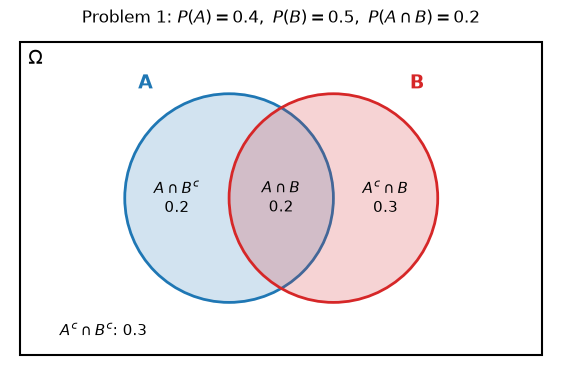

In [2]:
fig, ax = plt.subplots(figsize=(7, 4.4))
venn(ax,
     [('A', (4, 3), 2, 'tab:blue', (2.4, 5.2)),
      ('B', (6, 3), 2, 'tab:red', (7.6, 5.2))],
     [(3.0, 3, '$A \\cap B^c$\n0.2'),
      (5.0, 3, '$A \\cap B$\n0.2'),
      (7.0, 3, '$A^c \\cap B$\n0.3'),
      (1.6, 0.45, '$A^c \\cap B^c$: 0.3')],
     'Problem 1: $P(A)=0.4,\\ P(B)=0.5,\\ P(A \\cap B)=0.2$')
plt.show()

(b) Compute P(A|B) and P(B|A).

$$P(A \mid B) = \frac{P(A \cap B)}{P(B)} = \frac{0.2}{0.5} = 0.4$$

$$P(B \mid A) = \frac{P(A \cap B)}{P(A)} = \frac{0.2}{0.4} = 0.5$$

(c) Are A and B independent? Are they disjoint?

**Independent: yes.** $P(A)P(B) = 0.4 \times 0.5 = 0.2 = P(A \cap B)$.
Equivalently, $P(A \mid B) = 0.4 = P(A)$ and $P(B \mid A) = 0.5 = P(B)$: learning that one event happened does not change the probability of the other.

**Disjoint: no.** $P(A \cap B) = 0.2 \neq 0$, so the circles overlap; $A$ and $B$ can happen together.

2. Two events that are disjoint
    - Given: $P(A) = 0.3, P(B) = 0.6, P(A \cap B) = 0.$

(a) Draw a Venn diagram consistent with these probabilities and label all regions.

Since $P(A \cap B) = 0$, the circles do not overlap.

| Region | Probability |
|---|---|
| $A$ (all of $A$ is "$A$ only") | $0.3$ |
| $B$ (all of $B$ is "$B$ only") | $0.6$ |
| $A \cap B$ | $0$ (empty) |
| neither: $A^c \cap B^c$ | $1 - (0.3 + 0.6) = 0.1$ |

Check: $0.3 + 0.6 + 0 + 0.1 = 1$.

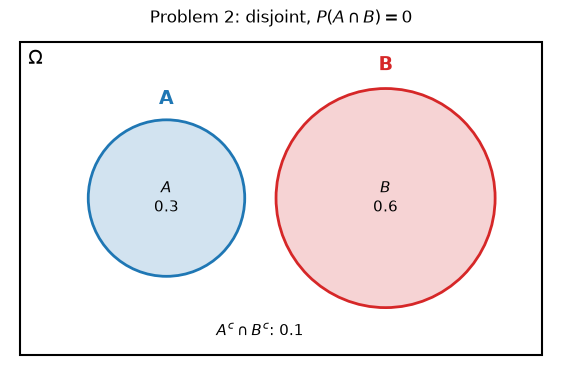

In [3]:
fig, ax = plt.subplots(figsize=(7, 4.4))
venn(ax,
     [('A', (2.8, 3), 1.5, 'tab:blue', (2.8, 4.9)),
      ('B', (7.0, 3), 2.1, 'tab:red', (7.0, 5.55))],
     [(2.8, 3, '$A$\n0.3'),
      (7.0, 3, '$B$\n0.6'),
      (4.6, 0.45, '$A^c \\cap B^c$: 0.1')],
     'Problem 2: disjoint, $P(A \\cap B)=0$')
plt.show()

(b) Are A and B independent? Explain why disjointness implies or does not imply independence.

**No, $A$ and $B$ are not independent.** Independence would require
$P(A \cap B) = P(A)P(B) = 0.3 \times 0.6 = 0.18$, but $P(A \cap B) = 0$.

Disjointness does **not** imply independence. In fact, disjoint events with nonzero probability are always **dependent**:
if $A$ happens then $B$ certainly did not, so $P(B \mid A) = 0 \neq 0.6 = P(B)$. Knowing $A$ tells us a lot about $B$.

Disjointness is a statement about sets (no shared outcomes). Independence is a statement about probabilities
($P(A \cap B) = P(A)P(B)$, i.e. knowing one event does not change the probability of the other).
The only way disjoint events can be independent is when $P(A) = 0$ or $P(B) = 0$, because then $P(A)P(B) = 0 = P(A \cap B)$.

3. Two events with overlap
    - Given: Sets $A$ and $B$ ovelap, $P(A) = 0.5, P(B) = 0.4, P(A \cap B) = 0.3$

(a) Draw a Venn diagram consistent with these probability and label all regions.

| Region | Probability |
|---|---|
| $A$ only: $A \cap B^c$ | $0.5 - 0.3 = 0.2$ |
| $A \cap B$ | $0.3$ |
| $B$ only: $A^c \cap B$ | $0.4 - 0.3 = 0.1$ |
| neither: $A^c \cap B^c$ | $1 - (0.5 + 0.4 - 0.3) = 0.4$ |

Check: $0.2 + 0.3 + 0.1 + 0.4 = 1$.

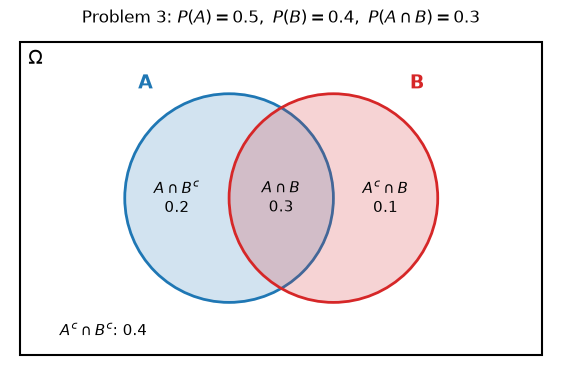

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.4))
venn(ax,
     [('A', (4, 3), 2, 'tab:blue', (2.4, 5.2)),
      ('B', (6, 3), 2, 'tab:red', (7.6, 5.2))],
     [(3.0, 3, '$A \\cap B^c$\n0.2'),
      (5.0, 3, '$A \\cap B$\n0.3'),
      (7.0, 3, '$A^c \\cap B$\n0.1'),
      (1.6, 0.45, '$A^c \\cap B^c$: 0.4')],
     'Problem 3: $P(A)=0.5,\\ P(B)=0.4,\\ P(A \\cap B)=0.3$')
plt.show()

(b) Are A and B independent?  Why?

**No.** $P(A)P(B) = 0.5 \times 0.4 = 0.2$, but $P(A \cap B) = 0.3 \neq 0.2$.

Equivalently, $P(A \mid B) = 0.3 / 0.4 = 0.75 \neq P(A) = 0.5$ and $P(B \mid A) = 0.3 / 0.5 = 0.6 \neq P(B) = 0.4$.
Knowing that $B$ happened makes $A$ more likely (and vice versa), so the events are positively dependent.
The overlap is larger than it would be under independence.

4. Subset and overlapping events (three sets)
    - Given three events $A, B, C$ with: $A \subset C$, $B$ overlaps $C$
      but is not a subset, and $A$ and $B$ are disjoint.

      $P(A) = 0.2, P(B) = 0.3, P(C) = 0.6, P(B \cap C) = 0.1, A \cap B = 0$.

(a) Draw a three-set Venn diagram consistent with these relations and label all regions.

Deriving the region probabilities:

* $A \subset C$, so $A \cap C = A$ and all of $A$ lies inside $C$: $P(A \cap C) = P(A) = 0.2$. The region $A \cap C^c$ is empty.
* $A \cap B = \emptyset$, so $A \cap B \cap C = \emptyset$ and the region $B \cap C$ lies entirely in $C \setminus A$.
* $C$ only ($C \cap A^c \cap B^c$): $P(C) - P(A) - P(B \cap C) = 0.6 - 0.2 - 0.1 = 0.3$. We can subtract both because $A$ and $B \cap C$ are disjoint pieces of $C$.
* $B$ only ($B \cap C^c$): $P(B) - P(B \cap C) = 0.3 - 0.1 = 0.2$.
* outside all three: $1 - (0.2 + 0.1 + 0.3 + 0.2) = 0.2$.

| Region | Probability |
|---|---|
| $A$ (inside $C$, outside $B$) | $0.2$ |
| $B \cap C$ (outside $A$) | $0.1$ |
| $C$ only | $0.3$ |
| $B$ only | $0.2$ |
| outside $A \cup B \cup C$ | $0.2$ |
| $A \cap B$, $A \cap C^c$, $A \cap B \cap C$ | $0$ (empty) |

Check: $0.2 + 0.1 + 0.3 + 0.2 + 0.2 = 1$.

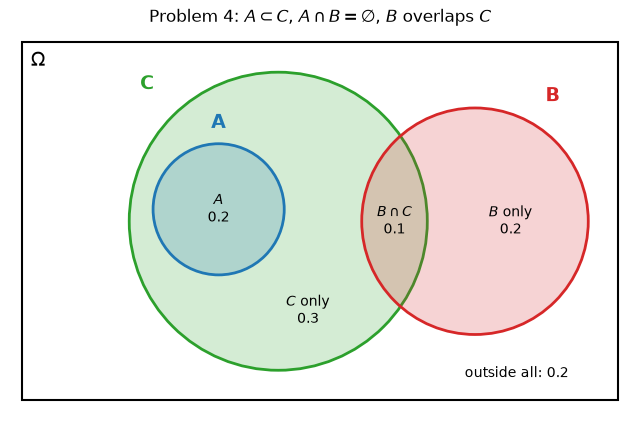

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
venn(ax,
     [('C', (4.3, 3), 2.5, 'tab:green', (2.1, 5.3)),
      ('A', (3.3, 3.2), 1.1, 'tab:blue', (3.3, 4.65)),
      ('B', (7.6, 3), 1.9, 'tab:red', (8.9, 5.1))],
     [(3.3, 3.2, '$A$\n0.2'),
      (4.8, 1.5, '$C$ only\n0.3'),
      (6.25, 3.0, '$B \\cap C$\n0.1'),
      (8.2, 3.0, '$B$ only\n0.2'),
      (8.3, 0.45, 'outside all: 0.2')],
     'Problem 4: $A \\subset C$, $A \\cap B = \\emptyset$, $B$ overlaps $C$',
     fontsize=10)
plt.show()

(b) Compute $P(A \cup B \cup C)$.

Inclusion-exclusion:

$$
\begin{aligned}
P(A \cup B \cup C) &= P(A) + P(B) + P(C) - P(A \cap B) - P(A \cap C) - P(B \cap C) + P(A \cap B \cap C) \\
&= 0.2 + 0.3 + 0.6 - 0 - 0.2 - 0.1 + 0 \\
&= 0.8
\end{aligned}
$$

using $P(A \cap C) = P(A) = 0.2$ (since $A \subset C$) and $P(A \cap B) = P(A \cap B \cap C) = 0$ (since $A$ and $B$ are disjoint).

Check 1: since $A \subset C$, $A \cup B \cup C = B \cup C$, so $P = P(B) + P(C) - P(B \cap C) = 0.3 + 0.6 - 0.1 = 0.8$.

Check 2: adding the non-empty regions inside the circles gives $0.2 + 0.1 + 0.3 + 0.2 = 0.8$, and $1 - 0.8 = 0.2$ is outside.

(c) Is any pair independent? Which pairs? Why?

**No pair is independent.** Compare each joint probability with the product of the marginals:

| Pair | $P(\text{joint})$ | Product of marginals | Independent? | Reason |
|---|---|---|---|---|
| $A, B$ | $P(A \cap B) = 0$ | $0.2 \times 0.3 = 0.06$ | No | Disjoint events with positive probability: $P(B \mid A) = 0 \neq 0.3$ |
| $A, C$ | $P(A \cap C) = 0.2$ | $0.2 \times 0.6 = 0.12$ | No | $A \subset C$: $P(C \mid A) = 1 \neq 0.6$. Knowing $A$ guarantees $C$ |
| $B, C$ | $P(B \cap C) = 0.1$ | $0.3 \times 0.6 = 0.18$ | No | $P(C \mid B) = 0.1 / 0.3 = 1/3 \neq 0.6$. Knowing $B$ makes $C$ less likely |

In general, a subset relation ($A \subset C$ with $P(C) < 1$) and disjointness (both with positive probability)
each rule out independence.

5. Conditional independence scenario
    - Setup: Describe events $A$ and $B$ that are not independent marginally
      but are independent conditional on event $C.$

(a) Sketch Venn diagrams for the joint distribution marginally
and the partition induced by $C$.

**Scenario (common cause).** A bag holds two coins. One is biased toward heads ($P(\text{H}) = 0.8$), the other toward tails ($P(\text{H}) = 0.2$).
Pick one coin at random and flip it twice.

* $C$ = "the heads-biased coin was picked" (so $C^c$ = "the tails-biased coin was picked")
* $A$ = "first flip is heads"
* $B$ = "second flip is heads"

Given which coin was picked, the two flips are independent. Marginally they are not: a heads on flip 1 is evidence
that we hold the heads-biased coin, which makes heads on flip 2 more likely.

The diagrams below show the same $A$/$B$ Venn diagram three times: marginally, and restricted to each cell of the partition
$\{C, C^c\}$. Each marginal region is the sum of the corresponding regions in the two partition cells
(e.g. $0.34 = 0.32 + 0.02$). Numbers are joint probabilities, with the conditional probability given the cell in parentheses.
The numbers come from part (b).

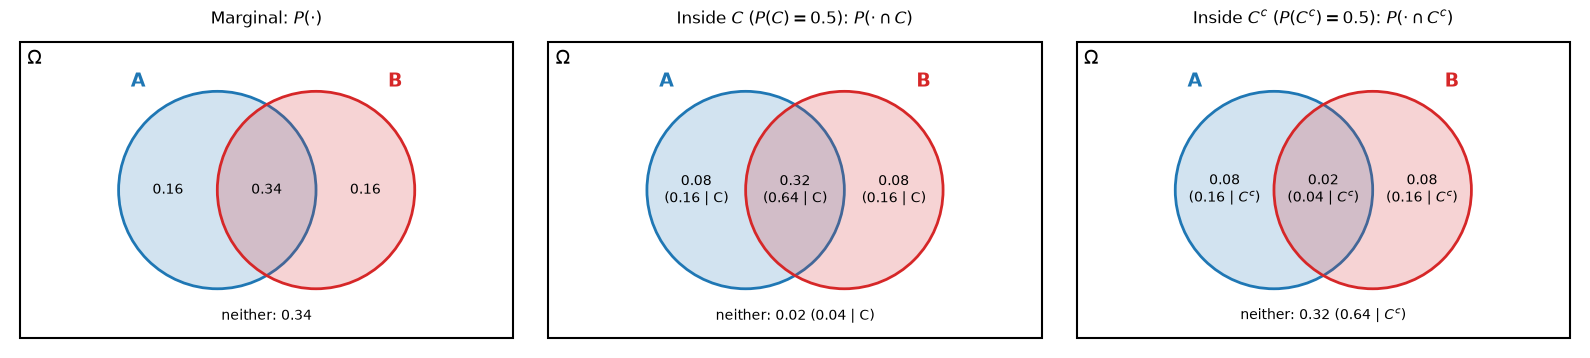

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
circles = [('A', (4, 3), 2, 'tab:blue', (2.4, 5.2)),
           ('B', (6, 3), 2, 'tab:red', (7.6, 5.2))]
panels = [
    ('Marginal: $P(\\cdot)$',
     ['0.16', '0.34', '0.16', 'neither: 0.34']),
    ('Inside $C$ ($P(C) = 0.5$): $P(\\cdot \\cap C)$',
     ['0.08\n(0.16 | C)', '0.32\n(0.64 | C)', '0.08\n(0.16 | C)', 'neither: 0.02 (0.04 | C)']),
    ('Inside $C^c$ ($P(C^c) = 0.5$): $P(\\cdot \\cap C^c)$',
     ['0.08\n(0.16 | $C^c$)', '0.02\n(0.04 | $C^c$)', '0.08\n(0.16 | $C^c$)', 'neither: 0.32 (0.64 | $C^c$)']),
]
for ax, (title, (a_only, ab, b_only, neither)) in zip(axes, panels):
    venn(ax, circles,
         [(3.0, 3, a_only), (5.0, 3, ab), (7.0, 3, b_only), (5.0, 0.45, neither)],
         title, fontsize=10)
plt.tight_layout()
plt.show()

(b) Provide a small numeric example (choose probabilities) that
satisfies:

$P(A \cap B) \ne P(A)P(B)$ but $P(A \cap B | C) = P(A|C)P(B|C)$.

Using the two-coin setup from (a):

$$P(C) = P(C^c) = 0.5, \qquad P(A \mid C) = P(B \mid C) = 0.8, \qquad P(A \mid C^c) = P(B \mid C^c) = 0.2$$

with the flips independent given the coin:

$$P(A \cap B \mid C) = 0.8 \times 0.8 = 0.64 = P(A \mid C)\,P(B \mid C) \;\checkmark$$

$$P(A \cap B \mid C^c) = 0.2 \times 0.2 = 0.04 = P(A \mid C^c)\,P(B \mid C^c) \;\checkmark$$

**Marginals** (law of total probability):

$$P(A) = P(A \mid C)P(C) + P(A \mid C^c)P(C^c) = 0.8(0.5) + 0.2(0.5) = 0.5, \qquad P(B) = 0.5 \text{ by symmetry}$$

$$P(A \cap B) = P(A \cap B \mid C)P(C) + P(A \cap B \mid C^c)P(C^c) = 0.64(0.5) + 0.04(0.5) = 0.34$$

**Not independent marginally:** $P(A \cap B) = 0.34 \neq 0.25 = P(A)P(B)$.
Equivalently $P(B \mid A) = 0.34 / 0.5 = 0.68 > 0.5 = P(B)$.

So $P(A \cap B) \ne P(A)P(B)$ but $P(A \cap B \mid C) = P(A \mid C)P(B \mid C)$, as required.

(c) Explain why conditioning can create or remove independence.

Independence is a property of a particular probability measure. Conditioning on $C$ replaces $P(\cdot)$ with
$P(\cdot \mid C) = P(\cdot \cap C)/P(C)$. This restricts the sample space to $C$ and renormalizes, so the product rule can hold under one measure and fail under the other.

**Conditioning can remove dependence (common cause).** In the coin example, $A$ and $B$ are dependent only because each carries
information about the hidden coin $C$. Once $C$ is known, flip 1 has nothing more to say about flip 2.
Mathematically, the marginal joint is a mixture of product distributions:

$$P(A \cap B) = \sum_{c \in \{C, C^c\}} P(A \mid c)\,P(B \mid c)\,P(c),$$

and a mixture of products is generally not a product. The mixing over $C$ creates the correlation.

**Conditioning can create dependence (common effect / "explaining away").** Flip two fair coins independently,
$A$ = "coin 1 heads", $B$ = "coin 2 heads", so $P(A \cap B) = 1/4 = P(A)P(B)$. Now condition on
$C$ = "at least one head" $= \{HH, HT, TH\}$:

$$P(A \mid C) = P(B \mid C) = 2/3, \qquad P(A \cap B \mid C) = 1/3 \neq 4/9.$$

Given $C$, learning that coin 1 was tails forces coin 2 to be heads. The event $C$ couples $A$ and $B$.

This matters in ML. For example, Naive Bayes assumes features are conditionally independent given the class,
even though they are clearly dependent marginally.

6. From a standard 52-card deck,
  let $A$ = "card is red", $B$ = "card is a face card (J,Q,K)",
  $C$ = "card is a heart".

(a) Draw Venn diagrams showing relationships between A, B, C (treat sets as colors and ranks). Label regions with counts or probabilities.

Relationships: every heart is red, so $C \subset A$. Face cards come in every suit, so $B$ overlaps
$C$ (heart face cards), overlaps $A \setminus C$ (diamond face cards), and extends outside $A$ (black face cards).

| Region | Cards | Count | Probability |
|---|---|---|---|
| $A \cap B \cap C$ | J♥, Q♥, K♥ | 3 | $3/52$ |
| $A \cap C \cap B^c$ | non-face hearts | 10 | $10/52$ |
| $A \cap C^c \cap B$ | J♦, Q♦, K♦ | 3 | $3/52$ |
| $A \cap C^c \cap B^c$ | non-face diamonds | 10 | $10/52$ |
| $A^c \cap B$ | black face cards | 6 | $6/52$ |
| $A^c \cap B^c$ (outside all) | black non-face cards | 20 | $20/52$ |
| $C \cap A^c$ | (none: no black hearts) | 0 | $0$ |

Check: $3 + 10 + 3 + 10 + 6 + 20 = 52$. Totals: $|A| = 26$, $|B| = 12$, $|C| = 13$.

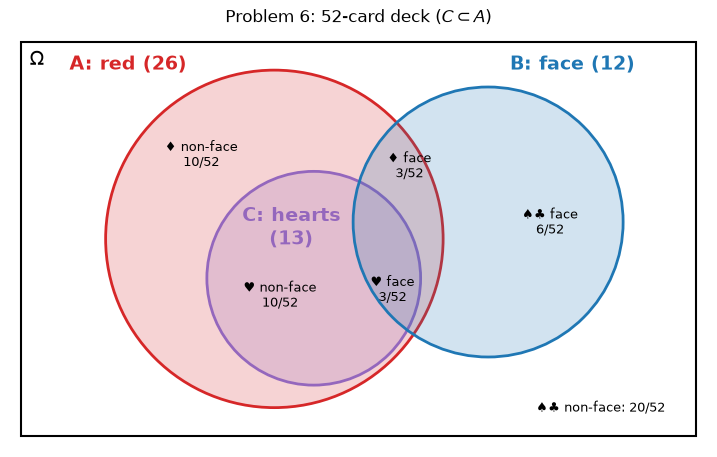

In [7]:
fig, ax = plt.subplots(figsize=(9, 5.5))
venn(ax,
     [('A: red (26)', (4.5, 3.5), 3.0, 'tab:red', (1.9, 6.6)),
      ('C: hearts\n(13)', (5.2, 2.8), 1.9, 'tab:purple', (4.8, 3.7)),
      ('B: face (12)', (8.3, 3.8), 2.4, 'tab:blue', (9.8, 6.6))],
     [(3.2, 5.0, '♦ non-face\n10/52'),
      (4.6, 2.5, '♥ non-face\n10/52'),
      (6.6, 2.6, '♥ face\n3/52'),
      (6.9, 4.8, '♦ face\n3/52'),
      (9.4, 3.8, '♠♣ face\n6/52'),
      (10.3, 0.5, '♠♣ non-face: 20/52')],
     'Problem 6: 52-card deck ($C \\subset A$)', size=(12, 7), fontsize=9)
plt.show()

(b) State which events are disjoint, which are subsets, and whether any pairs are independent.

**Disjoint:** no pair is disjoint. $A \cap B$ = 6 red face cards, $A \cap C$ = 13 hearts, $B \cap C$ = 3 heart face cards.

**Subsets:** $C \subset A$ (every heart is red). $B$ is not a subset of $A$ or $C$ (black face cards, diamond face cards),
and neither $A$ nor $C$ is a subset of $B$.

**Independence** (with $P(A) = 26/52 = 1/2$, $P(B) = 12/52 = 3/13$, $P(C) = 13/52 = 1/4$):

| Pair | $P(\text{joint})$ | Product of marginals | Independent? |
|---|---|---|---|
| $A, B$ | $6/52 = 3/26$ | $\frac12 \cdot \frac{3}{13} = 3/26$ | **Yes.** Half of the face cards are red, the same as half the deck. |
| $B, C$ | $3/52$ | $\frac{3}{13} \cdot \frac14 = 3/52$ | **Yes.** 3 of 13 hearts are face cards, the same fraction as in the deck. |
| $A, C$ | $P(C) = 13/52 = 1/4$ | $\frac12 \cdot \frac14 = 1/8$ | **No.** $C \subset A$ gives $P(A \mid C) = 1 \ne 1/2$. |

Note: the three events are not *mutually* independent: $P(A \cap B \cap C) = 3/52 \neq P(A)P(B)P(C) = 3/104$
(and $A, C$ already fail pairwise).

### Part B. Discrete Random Variables

7. Basic conditional probability and independence
    - Given events A and B with P(A) = 0.45, P(B) = 0.30, and P(A ∩ B) = 0.135:

(a) Compute P(A|B) and P(B|A).

$$P(A \mid B) = \frac{P(A \cap B)}{P(B)} = \frac{0.135}{0.30} = 0.45$$

$$P(B \mid A) = \frac{P(A \cap B)}{P(A)} = \frac{0.135}{0.45} = 0.30$$

(b) Are A and B independent? Justify your answer.

**Yes, $A$ and $B$ are independent.** $P(A)P(B) = 0.45 \times 0.30 = 0.135 = P(A \cap B)$.

Equivalently, from (a), $P(A \mid B) = 0.45 = P(A)$ and $P(B \mid A) = 0.30 = P(B)$: conditioning on one event does not change the probability of the other.

8. Bayes' rule — medical test example
    - A disease has prevalence 1%. A diagnostic test has sensitivity 95% (P(test+ | disease))
      and specificity 90% (P(test- | no disease)).

(a) Compute P(disease | test+).

Let $D$ = has disease, $+$ / $-$ = test result.

* Prevalence (prior): $P(D) = 0.01$, $P(D^c) = 0.99$
* Sensitivity: $P(+ \mid D) = 0.95$, so $P(- \mid D) = 0.05$
* Specificity: $P(- \mid D^c) = 0.90$, so the false positive rate is $P(+ \mid D^c) = 0.10$

Total probability of a positive test:

$$P(+) = P(+ \mid D)P(D) + P(+ \mid D^c)P(D^c) = 0.95(0.01) + 0.10(0.99) = 0.0095 + 0.099 = 0.1085$$

Bayes' rule:

$$P(D \mid +) = \frac{P(+ \mid D)P(D)}{P(+)} = \frac{0.0095}{0.1085} \approx 0.0876$$

**Only about 8.8%** of people who test positive actually have the disease.

(b) Compute P(no disease | test-).

$$P(-) = P(- \mid D)P(D) + P(- \mid D^c)P(D^c) = 0.05(0.01) + 0.90(0.99) = 0.0005 + 0.891 = 0.8915$$

(check: $1 - P(+) = 1 - 0.1085 = 0.8915$ ✓)

$$P(D^c \mid -) = \frac{P(- \mid D^c)P(D^c)}{P(-)} = \frac{0.891}{0.8915} \approx 0.9994$$

A negative result is very reliable: about **99.94%** of people who test negative are disease-free.

(c) Explain how prevalence affects the posterior probability.

Prevalence is the **prior** $P(D)$ in Bayes' rule. In odds form:

$$\underbrace{\frac{P(D \mid +)}{P(D^c \mid +)}}_{\text{posterior odds}} = \underbrace{\frac{P(+ \mid D)}{P(+ \mid D^c)}}_{\text{likelihood ratio} = 0.95/0.10 = 9.5} \times \underbrace{\frac{P(D)}{P(D^c)}}_{\text{prior odds}}$$

A positive test multiplies the odds by 9.5. At 1% prevalence the prior odds are $1/99$, so the posterior odds are only
$9.5/99 \approx 0.096$, giving $P(D \mid +) \approx 0.0876$.

When the disease is rare, the healthy population is huge. Even a 10% false-positive rate on 99% of people ($0.099$)
swamps the true positives from 1% of people ($0.0095$): roughly 10 false alarms per real case.

The same test gives very different posteriors at different prevalences:

| Prevalence $P(D)$ | $P(D \mid +)$ |
|---|---|
| 0.1% | 0.94% |
| 1% | 8.76% |
| 10% | 51.4% |
| 50% | 90.5% |

Higher prevalence gives a higher $P(D \mid +)$. Conversely, low prevalence makes a negative result even more trustworthy
($P(D^c \mid -)$ close to 1). This is why a positive screening test is usually followed by a confirmatory test, and why
testing high-risk groups (higher prior) gives more informative positives.

9. Chain rule and conditional probability with three events
    - Let $A, B, C$ be events with $P(A) = 0.6, P(B | A) = 0.5, P(B | A^c) = 0.2,
      P(C | A \cap B) = 0.9, P(C | A \cap B^c) = 0.4, P(C | A^c \cap B) = 0.7, P(C | A^c \cap B^c) = 0.1.$

(a) Use the chain rule and total probability to compute $P(A \cap B \cap C)$.

Chain rule (multiplication rule):

$$P(A \cap B \cap C) = P(A)\,P(B \mid A)\,P(C \mid A \cap B) = 0.6 \times 0.5 \times 0.9 = 0.27$$

The branches for part (b) come from the same chain rule applied to all four $(A, B)$ combinations,
with $P(A^c) = 1 - 0.6 = 0.4$, $P(B^c \mid A) = 0.5$, $P(B^c \mid A^c) = 0.8$.
Total probability also gives $P(B) = P(B \mid A)P(A) + P(B \mid A^c)P(A^c) = 0.5(0.6) + 0.2(0.4) = 0.38$.

(b) Compute $P(C)$ and $P(A | C)$.

Partition the sample space by $(A, B)$ and apply the chain rule to each branch:

| Branch | $P(\text{branch})$ | $P(C \mid \text{branch})$ | $P(C \cap \text{branch})$ |
|---|---|---|---|
| $A \cap B$ | $0.6 \times 0.5 = 0.30$ | $0.9$ | $0.270$ |
| $A \cap B^c$ | $0.6 \times 0.5 = 0.30$ | $0.4$ | $0.120$ |
| $A^c \cap B$ | $0.4 \times 0.2 = 0.08$ | $0.7$ | $0.056$ |
| $A^c \cap B^c$ | $0.4 \times 0.8 = 0.32$ | $0.1$ | $0.032$ |
| **Total** | $1.00$ ✓ | | $0.478$ |

**Law of total probability:**

$$P(C) = 0.270 + 0.120 + 0.056 + 0.032 = 0.478$$

**Bayes' rule:** $P(A \cap C) = P(A \cap B \cap C) + P(A \cap B^c \cap C) = 0.27 + 0.12 = 0.39$, so

$$P(A \mid C) = \frac{P(A \cap C)}{P(C)} = \frac{0.39}{0.478} \approx 0.816$$

10. Draw a 5-card hand uniformly at random from a standard $52$-card deck (without replacement).

(a) Compute the probability the hand contains exactly two pairs (two distinct
ranks each appearing twice, plus a fifth card of a different rank). Give the
answer in terms of binomial coefficients (e.g., $n$ choose $k$).

Count the "two pair" hands:

1. Choose the 2 ranks that form the pairs: $\binom{13}{2} = 78$. Unordered, so a pair of 5s and a pair of 9s is counted once.
2. Choose 2 of the 4 suits for each pair: $\binom{4}{2}^2 = 6^2 = 36$.
3. Choose the rank of the fifth card from the 11 remaining ranks: $\binom{11}{1} = 11$.
4. Choose its suit: $\binom{4}{1} = 4$.

$$P(\text{two pair}) = \frac{\binom{13}{2}\binom{4}{2}^2\binom{11}{1}\binom{4}{1}}{\binom{52}{5}}
= \frac{78 \cdot 36 \cdot 11 \cdot 4}{2{,}598{,}960} = \frac{123{,}552}{2{,}598{,}960} = \frac{198}{4165} \approx 0.0475$$

(b) Compute the probability the hand contains at least one ace. Express
using complementary counting and combinatorial terms.

Complement: "at least one ace" is the complement of "no aces", and a hand with no aces is 5 cards chosen from the 48 non-aces.

$$P(\text{no ace}) = \frac{\binom{48}{5}}{\binom{52}{5}} = \frac{1{,}712{,}304}{2{,}598{,}960} \approx 0.6588$$

$$P(\text{at least one ace}) = 1 - \frac{\binom{48}{5}}{\binom{52}{5}} = \frac{2{,}598{,}960 - 1{,}712{,}304}{2{,}598{,}960} = \frac{886{,}656}{2{,}598{,}960} = \frac{18472}{54145} \approx 0.3412$$

(c) Given the hand contains at least one ace, compute the conditional
probability that it contains exactly two aces.

Let $E_2$ = "exactly two aces" and $E_{\ge 1}$ = "at least one ace". Since $E_2 \subset E_{\ge 1}$, $P(E_2 \cap E_{\ge 1}) = P(E_2)$.

Exactly two aces: choose 2 of the 4 aces and 3 of the 48 non-aces:

$$P(E_2) = \frac{\binom{4}{2}\binom{48}{3}}{\binom{52}{5}} = \frac{6 \cdot 17{,}296}{2{,}598{,}960} = \frac{103{,}776}{2{,}598{,}960}$$

$$P(E_2 \mid E_{\ge 1}) = \frac{P(E_2)}{P(E_{\ge 1})} = \frac{\binom{4}{2}\binom{48}{3}}{\binom{52}{5} - \binom{48}{5}} = \frac{103{,}776}{886{,}656} = \frac{1081}{9236} \approx 0.117$$

(The $\binom{52}{5}$ denominators cancel.)

In [8]:
# Numerical check of problem 10 (exact counts with math.comb)
from math import comb
total = comb(52, 5)
two_pair = comb(13, 2) * comb(4, 2)**2 * comb(11, 1) * comb(4, 1)
at_least_one_ace = total - comb(48, 5)
exactly_two_aces = comb(4, 2) * comb(48, 3)
print(f"(a) P(two pair)                = {two_pair}/{total} = {two_pair / total:.5f}")
print(f"(b) P(at least one ace)        = {at_least_one_ace}/{total} = {at_least_one_ace / total:.5f}")
print(f"(c) P(exactly 2 aces | >= 1)   = {exactly_two_aces}/{at_least_one_ace} = {exactly_two_aces / at_least_one_ace:.5f}")

(a) P(two pair)                = 123552/2598960 = 0.04754
(b) P(at least one ace)        = 886656/2598960 = 0.34116
(c) P(exactly 2 aces | >= 1)   = 103776/886656 = 0.11704


11. Probability Mass Functions (PMF)

    - Let $X$ be a discrete random variable with the following probability mass function (PMF):

    $$
    P(X = x) =
    \begin{cases}
    0.1 & \text{if } x = 1, \\
    0.2 & \text{if } x = 2, \\
    0.3 & \text{if } x = 3, \\
    0.4 & \text{if } x = 4, \\
    0 & \text{otherwise.}
    \end{cases}
    $$

(a) Verify that this is a valid PMF.

A PMF is valid if (1) every probability is non-negative and (2) the probabilities sum to 1.

1. $0.1, 0.2, 0.3, 0.4 \ge 0$, and all other values have probability $0$. ✓
2. $\sum_x P(X = x) = 0.1 + 0.2 + 0.3 + 0.4 = 1.0$ ✓

(Each value is also $\le 1$, which follows from 1 and 2.) So this is a valid PMF.

(b) Compute $P(X \leq 3)$.

$$P(X \le 3) = P(X=1) + P(X=2) + P(X=3) = 0.1 + 0.2 + 0.3 = 0.6$$

(check: $1 - P(X = 4) = 1 - 0.4 = 0.6$ ✓)

(c) Compute the expected value $\mathbb{E}[X]$.

$$\mathbb{E}[X] = \sum_x x\,P(X=x) = 1(0.1) + 2(0.2) + 3(0.3) + 4(0.4) = 0.1 + 0.4 + 0.9 + 1.6 = 3.0$$

(d) Compute the variance $\text{Var}(X)$.

$$\mathbb{E}[X^2] = \sum_x x^2 P(X=x) = 1(0.1) + 4(0.2) + 9(0.3) + 16(0.4) = 0.1 + 0.8 + 2.7 + 6.4 = 10.0$$

$$\mathrm{Var}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2 = 10.0 - 3.0^2 = 1.0$$

Check with the definition $\mathrm{Var}(X) = \mathbb{E}[(X - \mu)^2]$, $\mu = 3$:
$(1-3)^2(0.1) + (2-3)^2(0.2) + (3-3)^2(0.3) + (4-3)^2(0.4) = 0.4 + 0.2 + 0 + 0.4 = 1.0$ ✓

12. Covariance of Random Variables

(a) Define the covariance $Cov[X,Y]$ of two random variables $X$ and $Y$ in terms of expectation.

$$\mathrm{Cov}[X, Y] = \mathbb{E}\big[(X - \mathbb{E}[X])(Y - \mathbb{E}[Y])\big]$$

For discrete random variables this is
$\mathrm{Cov}[X, Y] = \sum_x \sum_y (x - \mu_X)(y - \mu_Y)\,P(X = x, Y = y)$, with $\mu_X = \mathbb{E}[X]$, $\mu_Y = \mathbb{E}[Y]$.
It measures how $X$ and $Y$ vary together: it is positive when they tend to be above (or below) their means at the same time.

(b) Let $X$ and $Y$ be discrete random variables, each taking values in $\{0, 1\}$, with joint PMF given by the table below.

| $P(X=x, Y=y)$ | $Y=0$ | $Y=1$ |
|---|---|---|
| $X=0$ | 0.4 | 0.1 |
| $X=1$ | 0.1 | 0.4 |

Compute $Cov[X,Y]$ directly from the definition in part (a). Are $X$ and $Y$ independent? Justify your answer using the marginal probabilities.

**Marginals** (sum the rows and columns):

* $P(X=0) = 0.4 + 0.1 = 0.5$, $P(X=1) = 0.1 + 0.4 = 0.5$, so $\mathbb{E}[X] = 0(0.5) + 1(0.5) = 0.5$
* $P(Y=0) = 0.4 + 0.1 = 0.5$, $P(Y=1) = 0.1 + 0.4 = 0.5$, so $\mathbb{E}[Y] = 0.5$

**Covariance from the definition:**

$$
\begin{aligned}
\mathrm{Cov}[X,Y] &= \sum_{x,y} (x - 0.5)(y - 0.5)\,P(X=x, Y=y) \\
&= (-0.5)(-0.5)(0.4) + (-0.5)(0.5)(0.1) + (0.5)(-0.5)(0.1) + (0.5)(0.5)(0.4) \\
&= 0.1 - 0.025 - 0.025 + 0.1 \\
&= 0.15
\end{aligned}
$$

(check with part (c): $\mathbb{E}[XY] = 1 \cdot 1 \cdot 0.4 = 0.4$, and $0.4 - 0.5 \times 0.5 = 0.15$ ✓)

**Not independent.** Independence requires $P(X=x, Y=y) = P(X=x)P(Y=y)$ for **every** cell, but

$$P(X=0, Y=0) = 0.4 \neq P(X=0)P(Y=0) = 0.5 \times 0.5 = 0.25.$$

One failing cell is enough. (Also, independence implies $\mathrm{Cov} = 0$, so $\mathrm{Cov} = 0.15 \neq 0$ already rules it out.)
$X$ and $Y$ tend to agree ($P(X = Y) = 0.8$), which is why the covariance is positive.

(c) Starting from the definition in part (a), show algebraically that $Cov[X,Y] = E[XY] - E[X]E[Y]$.

Let $\mu_X = \mathbb{E}[X]$ and $\mu_Y = \mathbb{E}[Y]$. These are constants, so they can be pulled out of expectations.
Expand the product and use linearity of expectation:

$$
\begin{aligned}
\mathrm{Cov}[X,Y] &= \mathbb{E}\big[(X - \mu_X)(Y - \mu_Y)\big] \\
&= \mathbb{E}\big[XY - \mu_Y X - \mu_X Y + \mu_X \mu_Y\big] \\
&= \mathbb{E}[XY] - \mu_Y\,\mathbb{E}[X] - \mu_X\,\mathbb{E}[Y] + \mu_X \mu_Y \\
&= \mathbb{E}[XY] - \mu_Y \mu_X - \mu_X \mu_Y + \mu_X \mu_Y \\
&= \mathbb{E}[XY] - \mu_X \mu_Y \\
&= \mathbb{E}[XY] - \mathbb{E}[X]\,\mathbb{E}[Y] \qquad \blacksquare
\end{aligned}
$$

### Part C. Continuous random variables — expectation and variance

For each problem below, show all integration steps and justify any changes of variables. Compute the expectation $\mathbb{E}[X]$ and the variance $\mathrm{Var}(X)$.

13. Let $X\sim\mathrm{Uniform}(a,b)$ with $-\infty<a<b<\infty$.

(a) Write the pdf $f_X(x)$ and verify it integrates to $1$.

$$
f_X(x) = \begin{cases} \dfrac{1}{b-a}, & a \le x \le b, \\[4pt] 0, & \text{otherwise.} \end{cases}
$$

$f_X(x) \ge 0$ everywhere (since $b > a$), and

$$\int_{-\infty}^{\infty} f_X(x)\,dx = \int_a^b \frac{1}{b-a}\,dx = \frac{1}{b-a}\Big[x\Big]_a^b = \frac{b-a}{b-a} = 1 \;\checkmark$$

(b) Compute $\mathbb{E}[X]$ and $\mathrm{Var}(X)$ in terms of $a,b$.

**Mean:**

$$\mathbb{E}[X] = \int_a^b \frac{x}{b-a}\,dx = \frac{1}{b-a}\left[\frac{x^2}{2}\right]_a^b = \frac{b^2 - a^2}{2(b-a)} = \frac{(b-a)(b+a)}{2(b-a)} = \frac{a+b}{2}$$

**Second moment:**

$$\mathbb{E}[X^2] = \int_a^b \frac{x^2}{b-a}\,dx = \frac{1}{b-a}\left[\frac{x^3}{3}\right]_a^b = \frac{b^3 - a^3}{3(b-a)} = \frac{(b-a)(a^2 + ab + b^2)}{3(b-a)} = \frac{a^2 + ab + b^2}{3}$$

**Variance:**

$$
\begin{aligned}
\mathrm{Var}(X) &= \mathbb{E}[X^2] - (\mathbb{E}[X])^2 = \frac{a^2 + ab + b^2}{3} - \frac{(a+b)^2}{4} \\
&= \frac{4a^2 + 4ab + 4b^2 - 3a^2 - 6ab - 3b^2}{12} = \frac{a^2 - 2ab + b^2}{12} = \frac{(b-a)^2}{12}
\end{aligned}
$$

14. Let $X$ have pdf

$$
f_X(x)=
\begin{cases}
kx^2, & 0\le x\le 1,\\[4pt]
0, & \text{otherwise.}
\end{cases}
$$

(a) Find the normalizing constant $k$.

The pdf must integrate to 1 (and $k > 0$ so that $f_X \ge 0$):

$$\int_0^1 kx^2\,dx = k\left[\frac{x^3}{3}\right]_0^1 = \frac{k}{3} = 1 \quad\Longrightarrow\quad k = 3$$

(b) Compute $\mathbb{E}[X]$ and $\mathrm{Var}(X)$.

With $f_X(x) = 3x^2$ on $[0, 1]$:

$$\mathbb{E}[X] = \int_0^1 x \cdot 3x^2\,dx = 3\left[\frac{x^4}{4}\right]_0^1 = \frac{3}{4}$$

$$\mathbb{E}[X^2] = \int_0^1 x^2 \cdot 3x^2\,dx = 3\left[\frac{x^5}{5}\right]_0^1 = \frac{3}{5}$$

$$\mathrm{Var}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2 = \frac{3}{5} - \frac{9}{16} = \frac{48 - 45}{80} = \frac{3}{80} = 0.0375$$

15. Let $X\sim\mathrm{Exponential}(\lambda)$ with $\lambda>0$, i.e. $f_X(x)=\lambda e^{-\lambda x}$ for $x\ge0$.
Compute $\mathbb{E}[X]$ and $\mathrm{Var}(X)$ (show the integrals).

**Valid pdf:** $\displaystyle\int_0^\infty \lambda e^{-\lambda x}\,dx = \Big[-e^{-\lambda x}\Big]_0^\infty = 0 - (-1) = 1$ ✓

**Mean.** Integrate by parts with $u = x$, $dv = \lambda e^{-\lambda x}dx$, so $du = dx$, $v = -e^{-\lambda x}$:

$$
\mathbb{E}[X] = \int_0^\infty x\,\lambda e^{-\lambda x}\,dx
= \Big[-x e^{-\lambda x}\Big]_0^\infty + \int_0^\infty e^{-\lambda x}\,dx
= 0 + \left[-\frac{1}{\lambda}e^{-\lambda x}\right]_0^\infty = \frac{1}{\lambda}
$$

The boundary term vanishes because $x e^{-\lambda x} \to 0$ as $x \to \infty$ (the exponential decays faster than $x$ grows) and it equals $0$ at $x = 0$.

**Second moment.** Integrate by parts with $u = x^2$, $dv = \lambda e^{-\lambda x}dx$, so $du = 2x\,dx$, $v = -e^{-\lambda x}$:

$$
\mathbb{E}[X^2] = \int_0^\infty x^2\,\lambda e^{-\lambda x}\,dx
= \Big[-x^2 e^{-\lambda x}\Big]_0^\infty + \int_0^\infty 2x\,e^{-\lambda x}\,dx
= 0 + \frac{2}{\lambda}\underbrace{\int_0^\infty x\,\lambda e^{-\lambda x}\,dx}_{=\,\mathbb{E}[X]\,=\,1/\lambda}
= \frac{2}{\lambda^2}
$$

**Variance:**

$$\mathrm{Var}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2 = \frac{2}{\lambda^2} - \frac{1}{\lambda^2} = \frac{1}{\lambda^2}$$

So $\mathbb{E}[X] = 1/\lambda$ and $\mathrm{Var}(X) = 1/\lambda^2$.

16. Surface Normals

Prove that the vector $\mathbf{n} = (\Theta_1, \Theta_2, \Theta_3)$ is a surface normal
to the plane given by $\mathbf{\Theta}^T\mathbf{x} = 0$ where $\mathbf{\Theta}$
is given by

$$
\mathbf{\Theta} = \begin{bmatrix}
  \Theta_0 \\
  \Theta_1 \\
  \Theta_2 \\
  \Theta_3
\end{bmatrix}
$$

$$
\mathbf{x} = \begin{bmatrix}
  1  \\
  x_1 \\
  x_2 \\
  x_3
\end{bmatrix}
$$

where $$(x_1, x_2, x_3)$$ is any point that lies on the plane.

**Hint:** one only needs to show that $\mathbf{n}$ is perpendicular to vectors in the plane.  Consider the definition and properties of the **dot product** to guide your proof.


Write $\mathbf{n} = (\Theta_1, \Theta_2, \Theta_3)$ and $\mathbf{p} = (x_1, x_2, x_3)$. Assume $\mathbf{n} \neq \mathbf{0}$; otherwise the equation does not describe a plane.
The plane equation is

$$\mathbf{\Theta}^T\mathbf{x} = \Theta_0 + \Theta_1 x_1 + \Theta_2 x_2 + \Theta_3 x_3 = \Theta_0 + \mathbf{n}\cdot\mathbf{p} = 0,$$

so **every** point $\mathbf{p}$ on the plane satisfies $\mathbf{n}\cdot\mathbf{p} = -\Theta_0$.

**Vectors in the plane.** Any vector $\mathbf{v}$ lying in the plane goes from one point of the plane to another,
so $\mathbf{v} = \mathbf{q} - \mathbf{p}$ for some points $\mathbf{p}, \mathbf{q}$ on the plane.

**Dot product.** By linearity of the dot product,

$$\mathbf{n}\cdot\mathbf{v} = \mathbf{n}\cdot(\mathbf{q} - \mathbf{p}) = \mathbf{n}\cdot\mathbf{q} - \mathbf{n}\cdot\mathbf{p} = (-\Theta_0) - (-\Theta_0) = 0.$$

**Perpendicularity.** Since $\mathbf{n}\cdot\mathbf{v} = \|\mathbf{n}\|\,\|\mathbf{v}\|\cos\varphi$, for any nonzero $\mathbf{v}$ in the plane
we get $\cos\varphi = 0$, so $\varphi = 90^\circ$. Thus $\mathbf{n}$ is perpendicular to every vector in the plane,
which is exactly the definition of a normal vector to the plane. $\blacksquare$

Remark: $\Theta_0$ cancels, so it only shifts the plane along $\mathbf{n}$ without changing its orientation.
The plane's distance from the origin is $|\Theta_0| / \|\mathbf{n}\|$.

17. Gradients

Some problems involving matrix calculus.  Even those who have taken a linear algebra course may not be
familiar with matrix calculus.   So let's do a few problems starting from the more familiar scalar calculus 
and then vector calculus.

* $x$ is a scalar. $f(x)$ is a scalar function means the output is a scalar. $\nabla = \nabla_x = \frac{d}{dx}$. Ex: $\nabla_x x^2 = 2x$.
* $\mathbf{x}$ is a vector.  $f(\mathbf{x})$ is a scalar function that takes a vector argument.

$$\nabla f(\mathbf{x}) = \begin{bmatrix}
  \frac{\partial f}{\partial x_1} \\
  \frac{\partial f}{\partial x_2} \\
  \vdots \\
  \frac{\partial f}{\partial x_n} \\
\end{bmatrix}
$$

#### Example II.1: Gradient of a paraboloid

$$f(\mathbf{x}) = -(x_1^2 + x_2^2)$$

$$\nabla f(\mathbf{x}) = \begin{bmatrix} -2x_1 \\ -2x_2 \end{bmatrix}$$

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def f(x1, x2):
    return -(x1**2 + x2**2)/10


# Generate the grid
x1 = np.linspace(-5, 5, 100)
x2 = np.linspace(-5, 5, 100)
X1, X2 = np.meshgrid(x1, x2)    # populates two dimensional arrays wherein one represents x-values and the other y-values
                                # This is a bit redundant, but numpy will evalute the function by sweeping across both
                                # matrices in parallel using vector operations.
Y = f(X1, X2)                   # evaluates at every (x1, x2) position in the X1, X2 matrices.



In [10]:
# Compute the gradients
#grad_x1, grad_x2 = np.gradient(Y, x1, x2)  This doesn't do what I expected.
#print(grad_x1)
#print(grad_x2)

grad_x1 = -2*X1/10
grad_x2 = -2*X2/10
#print(gradX1)

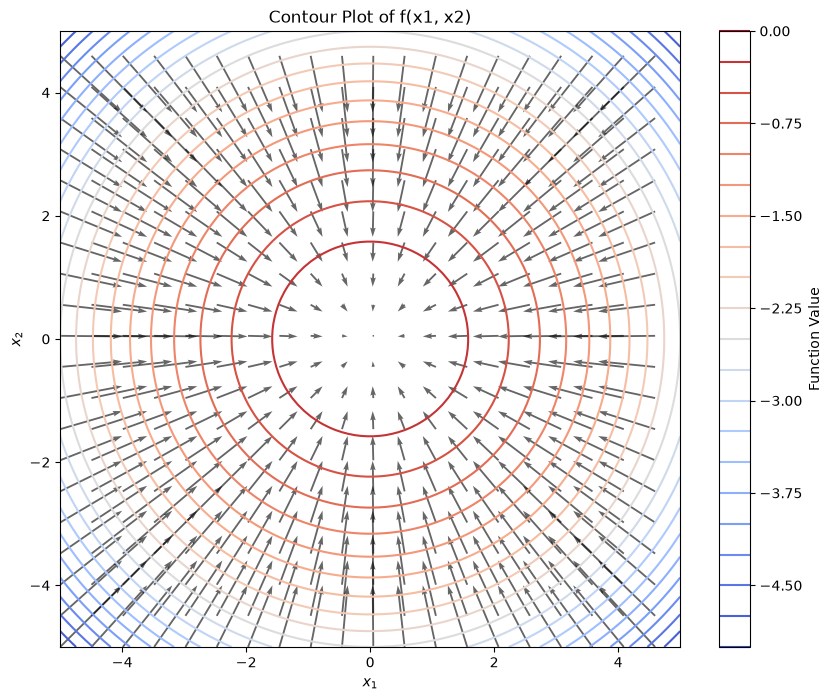

In [11]:
# Select every 5th point for a sparse quiver plot
skip = (slice(None, None, 5), slice(None, None, 5))

# Plot the contour and the sparser gradients
plt.figure(figsize=(10, 8))
contour = plt.contour(X1, X2, Y, levels=20, cmap='coolwarm')
plt.quiver(X1[skip], X2[skip], grad_x1[skip], grad_x2[skip], color='black', angles='xy', scale_units='xy', scale=1, alpha=0.6)

# Add labels and display the plot
plt.title("Contour Plot of f(x1, x2)")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.colorbar(contour, label="Function Value")
plt.show()

#### Example II.2: Gradient of a highly eccentric ellipsoid

$$f(\mathbf{x}) = -10x_1^2 -x_2^2,\quad \nabla f(\mathbf{x}) = \begin{bmatrix}
  \frac{\partial}{\partial x_1} -10x_1^2 -x_2^2 \\
  \frac{\partial}{\partial x_2} -10x_1^2 -x_2^2
\end{bmatrix} = \begin{bmatrix}
-20 x_1 \\
-2 x_2
\end{bmatrix}$$
  

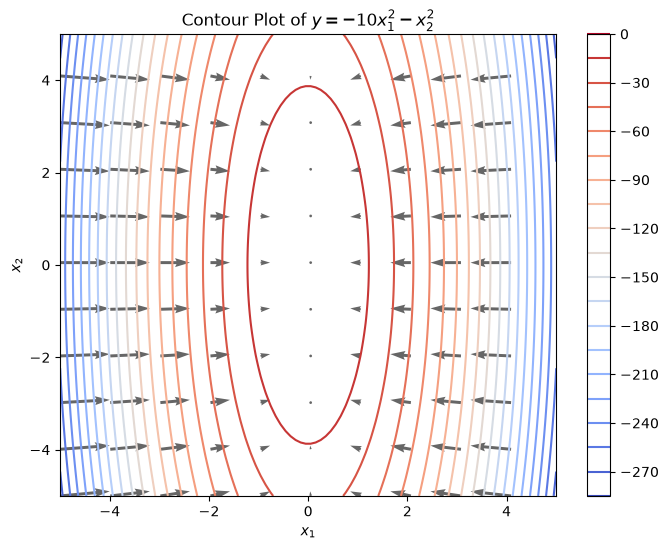

In [12]:
a = -10
b = -1

grad_scale = 1  # scaling factor for the gradient vectors

# Define a new function for the more eccentric ellipsoid
def ellipsoid(x1, x2):
    return a * x1**2 + b * x2**2

x1 = np.linspace(-5, 5, 100)
x2 = np.linspace(-5, 5, 100)
X1, X2 = np.meshgrid(x1, x2)    # populates two dimensional arrays wherein one represents x-values and the other y-values
                                # This is a bit redundant, but numpy will evalute the function by sweeping across both
                                # matrices in parallel using vector operations.
Y = ellipsoid(X1, X2)           # evaluates at every (x1, x2) position in the X1, X2 matrices.

# Adjust spacing to reduce the number of gradient vectors
new_spacing = 10  
X1_sub = X1[::new_spacing, ::new_spacing]
X2_sub = X2[::new_spacing, ::new_spacing]

# Compute gradient vectors 
grad_x1 = grad_scale * 2 * a * X1_sub
grad_x2 = grad_scale * 2 * b * X2_sub

# Plot the contour plot with selectively placed gradient vectors on the more eccentric ellipsoid
plt.figure(figsize=(8, 6))
contour = plt.contour(X1, X2, Y, levels=20, cmap="coolwarm")
plt.colorbar(contour)

# Add fewer gradient vectors selectively at level curve positions
plt.quiver(X1_sub, X2_sub, grad_x1, grad_x2, color='black', angles='xy', scale_units='xy', scale=100, alpha=0.6)

plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.title(r'Contour Plot of $y = -10x_1^2 - x_2^2$')
plt.show()

Note that the gradient vectors in the ellipsoid contour plot do not all point directly at the peak.  Instead
they point perpendicular to the contour curves.  

#### Example II.3: Colliding flows

$$
f(\mathbf{x}) = x_1 x_2^2 + a x_2,\quad \\
\nabla f(\mathbf{x}) = \begin{bmatrix}
  \frac{\partial}{\partial x_1} x_1 x_2^2 + a x_2 \\
  \frac{\partial}{\partial x_2} x_1 x_2^2 + a x_2
\end{bmatrix} = 
\begin{bmatrix}
  x_2^2 \\
  2 x_1 x_2 + a
\end{bmatrix}
$$

In [13]:
a = 0.5

def f(x1, x2):
    return x1 * x2**2 + a * x2

Y = f(X1, X2) 

# compute gradient
grad_x1 = X2**2   # performs an elementwise squaring.  It is taking the Hadamard product of X2 with itself.
grad_x2 = 2 * X1 * X2 + a


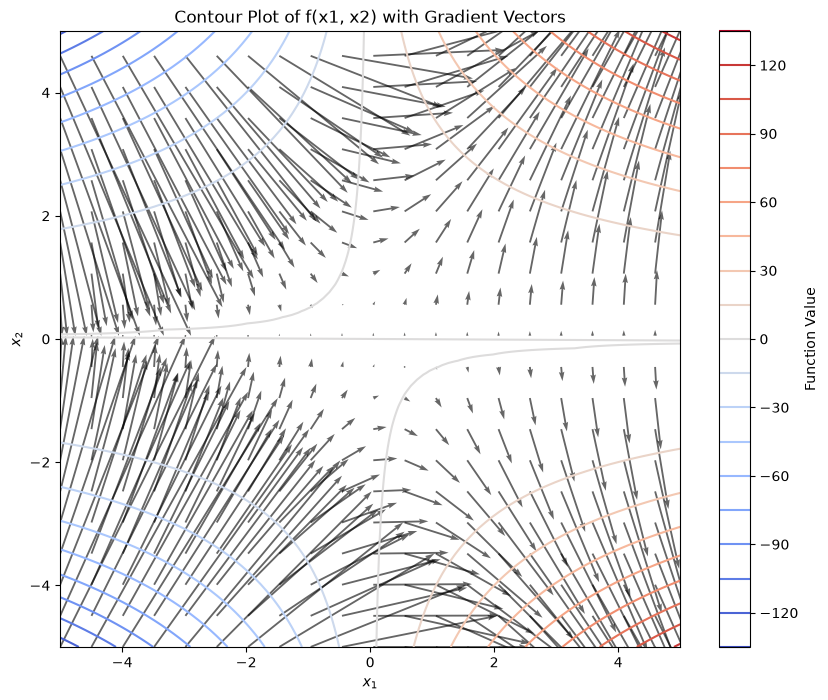

In [14]:
# Select every 5th point for a sparse quiver plot
skip = (slice(None, None, 5), slice(None, None, 5))

# Plot the contour and the sparser gradients
plt.figure(figsize=(10, 8))
contour = plt.contour(X1, X2, Y, levels=20, cmap='coolwarm')
plt.quiver(X1[skip], X2[skip], grad_x1[skip], grad_x2[skip], color='black', angles='xy', scale_units='xy', scale=10, alpha=0.6)

# Add labels and display the plot
plt.title("Contour Plot of f(x1, x2) with Gradient Vectors")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.colorbar(contour, label="Function Value")
plt.show()

* $\mathbf{x}$ is a vector, $y$ is a scalar.

$$\nabla_{\mathbf{x}} f(\mathbf{x},y) = \begin{bmatrix}
  \frac{\partial f}{\partial x_1} \\
  \frac{\partial f}{\partial x_2} \\
  \vdots \\
  \frac{\partial f}{\partial x_n} \\
\end{bmatrix}
$$ 

When we specify a subscript to the $\nabla$ the gradient is only taken with respect to the variables specified
in the subscript.


#### Example II.4:

$$
f(\mathbf{x}, y) = x_1 x_2^2 y + a x_2,\quad \\
\nabla_\mathbf{x} f(\mathbf{x}, y) = \begin{bmatrix}
  \frac{\partial}{\partial x_1} x_1 x_2^2 y + a x_2 \\
  \frac{\partial}{\partial x_2} x_1 x_2^2 y + a x_2
\end{bmatrix} = 
\begin{bmatrix}
  y x_2^2 \\
  2 x_1 x_2 y + a
\end{bmatrix}
$$

* $\mathbf{x}$ is a column vector.  $A$ is a square matrix.  $f(\mathbf{x}) = \mathbf{x}^T A \mathbf{x}$.

Because $f(\mathbf{x}) = \mathbf{x}^T A \mathbf{x}$ is a scalar function, we can apply the gradient.

#### Example II.5:

$$\text{let } A = \begin{bmatrix}
    2 & 1 \\
    1 & 3
  \end{bmatrix},\quad 
  \mathbf{x} = \begin{bmatrix}
    x_1 \\
    x_2
  \end{bmatrix},\quad
  f(\mathbf{x}) = \mathbf{x}^T A \mathbf{x}
$$

Find $\nabla_{\mathbf{x}} f(\mathbf{x})$.

\begin{align}
  \nabla_{\mathbf{x}}
  \begin{bmatrix}
    x_1 \\
    x_2
  \end{bmatrix}^T \begin{bmatrix}
    2 & 1 \\
    1 & 3
  \end{bmatrix} 
  \begin{bmatrix}
    x_1 \\
    x_2
  \end{bmatrix}
&= \nabla_{\mathbf{x}}
  \begin{bmatrix}
    2 x_1 + x_2 & x_1 + 3 x_2
  \end{bmatrix} 
  \begin{bmatrix}
    x_1 \\
    x_2
  \end{bmatrix} \\
  \\
&= \begin{bmatrix}
  \frac{\partial}{\partial x_1} (2 x_1^2 + x_1 x_2 + x_1 x_2 + 3 x_2^2) \\
  \frac{\partial}{\partial x_2} (2 x_1^2 + x_1 x_2 + x_1 x_2 + 3 x_2^2)
  \end{bmatrix} \\
  \\
&= \begin{bmatrix}
    4 x_1 + 2 x_2 \\
    2 x_1 + 6 x_2
  \end{bmatrix} \\
  \\
&= 2 \begin{bmatrix}
    2 x_1 + x_2 \\
    x_1 + 3x_2
  \end{bmatrix} \\
  \\
&= 2 \begin{bmatrix}
 2 & 1 \\
 1 & 3
\end{bmatrix}
  \begin{bmatrix}
    x_1 \\
    x_2
  \end{bmatrix} \\
  \\
&= 2 A \mathbf{x}
\end{align}

This is analogous to taking the derivative of the 1-d scalar function of $f(x) = a x^2$.

$$\frac{d}{dx} f(x) = \frac{d}{dx} a x^2 = 2 a x$$

Example II.5, illustrates a general matrix calculus rule for the case when $A$ is symmetric, i.e., $A = A^T$:

$$\nabla_{\mathbf{x}}~\mathbf{x}^T A \mathbf{x} = 2 A \mathbf{x}$$


(a) From Example II.4, find $\nabla_y f(\mathbf{x}, y)$.

$f(\mathbf{x}, y) = x_1 x_2^2 y + a x_2$. Since $y$ is a scalar, $\nabla_y$ is just the partial derivative with respect to $y$,
treating $x_1, x_2$ (and the constant $a$) as constants. The term $a x_2$ does not depend on $y$:

$$\nabla_y f(\mathbf{x}, y) = \frac{\partial}{\partial y}\left(x_1 x_2^2 y + a x_2\right) = x_1 x_2^2$$

(b) Given $f(\mathbf{x}) = (x_1+2)^2 - (x_2 -1)^2$, find $\nabla f(\mathbf{x})$, the gradient of $f$ with respect to $\mathbf{x}$.  Note: $\nabla f(\mathbf{x}) = \nabla_{\mathbf{x}} f(\mathbf{x})$ since $\mathbf{x} = (x_1, x_2)$ includes all variables in $f(\mathbf{x})$.

$$
\nabla f(\mathbf{x}) = \begin{bmatrix}
  \frac{\partial}{\partial x_1}\left[(x_1+2)^2 - (x_2-1)^2\right] \\
  \frac{\partial}{\partial x_2}\left[(x_1+2)^2 - (x_2-1)^2\right]
\end{bmatrix}
= \begin{bmatrix}
  2(x_1 + 2) \\
  -2(x_2 - 1)
\end{bmatrix}
= \begin{bmatrix}
  2x_1 + 4 \\
  -2x_2 + 2
\end{bmatrix}
$$

The gradient is zero at $(x_1, x_2) = (-2, 1)$. This point is a **saddle**: $f$ curves upward along $x_1$ and downward along $x_2$.

(c) Plot the contour plot for $\nabla f(\mathbf{x})$ given in part (b), overlaying gradient vectors.

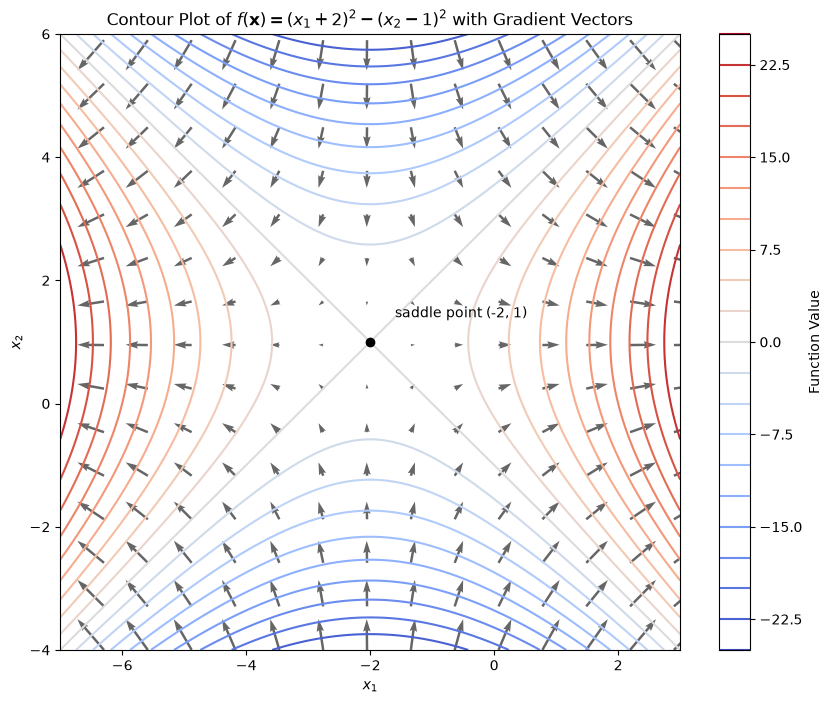

In [15]:
def f(x1, x2):
    return (x1 + 2)**2 - (x2 - 1)**2

# Grid centered on the stationary point (-2, 1)
x1 = np.linspace(-7, 3, 100)
x2 = np.linspace(-4, 6, 100)
X1, X2 = np.meshgrid(x1, x2)
Y = f(X1, X2)

# Gradient from part (b)
grad_x1 = 2 * (X1 + 2)
grad_x2 = -2 * (X2 - 1)

# Select every 7th point for a sparse quiver plot
skip = (slice(None, None, 7), slice(None, None, 7))

plt.figure(figsize=(10, 8))
contour = plt.contour(X1, X2, Y, levels=20, cmap='coolwarm')
plt.quiver(X1[skip], X2[skip], grad_x1[skip], grad_x2[skip], color='black',
           angles='xy', scale_units='xy', scale=20, alpha=0.6)
plt.plot(-2, 1, 'ko')
plt.annotate('saddle point (-2, 1)', xy=(-2, 1), xytext=(-1.6, 1.4))

plt.title(r"Contour Plot of $f(\mathbf{x}) = (x_1+2)^2 - (x_2-1)^2$ with Gradient Vectors")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.colorbar(contour, label="Function Value")
plt.show()

(d) Find $\nabla_\mathbf{x} f(\mathbf{x})$ where $f(\mathbf{x}) = \mathbf{a}^T \mathbf{x}$ and 

$$
\mathbf{a} = \begin{bmatrix}
  2 \\
  4 \\ 
  -7
\end{bmatrix}, \quad
\mathbf{x} = \begin{bmatrix}
  x_1 \\
  x_2 \\
  x_3
\end{bmatrix}
$$


$f(\mathbf{x}) = \mathbf{a}^T\mathbf{x} = 2x_1 + 4x_2 - 7x_3$, so

$$
\nabla_{\mathbf{x}} f(\mathbf{x}) = \begin{bmatrix}
  \frac{\partial}{\partial x_1}(2x_1 + 4x_2 - 7x_3) \\
  \frac{\partial}{\partial x_2}(2x_1 + 4x_2 - 7x_3) \\
  \frac{\partial}{\partial x_3}(2x_1 + 4x_2 - 7x_3)
\end{bmatrix}
= \begin{bmatrix} 2 \\ 4 \\ -7 \end{bmatrix} = \mathbf{a}
$$

This is the general rule $\nabla_{\mathbf{x}}\,\mathbf{a}^T\mathbf{x} = \mathbf{a}$, the vector analogue of $\frac{d}{dx}(ax) = a$.
The gradient is constant: a linear function increases fastest in the direction $\mathbf{a}$ everywhere.

18. Linear Regression Normal Equation

For linear regression as illustrated below, training data set $\{\mathbf{x}^{(i)}\}$ is input into a training algorithm.  The training algo is labelled below as "training algo."  The $i^{th}$ sample in the input training data set is a vector denoted by $\mathbf{x}^{(i)}$.  For each input in the training data set $\mathbf{x}^{(i})$ there is the associated scalar training data output $y^{(i)}$.  The ouput data in the training data set
is also called the *observed data*.   From the input and output training data, the training algo infers a set of parameters that characterize a hypothesis $h$.   The $h$ hypothesis is also
called "the model."  Given that the hypothesis is configured by parameters $\Theta$, $h$ is often denoted by $h_{\Theta}$.

In the context of linear regression, $h_{\Theta}(\mathbf{x})$ is a linear combination of the input features $\mathbf{x}$ and thus can be represented as a column vector $\Theta$.  If the input data has $n$ dimensions and $\mathbf{x}$ is represetned with a 1 as the first
element then $\mathbf{x}$ and $\Theta$ can be written

$$
\mathbf{x} = \begin{bmatrix}
   1 \\
   x_1 \\
   x_2 \\
   \vdots \\
   x_n 
\end{bmatrix}
,\quad \Theta = \begin{bmatrix}
   \Theta_0 \\
   \Theta_1 \\
   \Theta_2 \\
   \vdots \\
   \Theta_n 
\end{bmatrix}
$$

The output is thus a function of the input as in 

$$
y = h_{\Theta}(\mathbf{x}) = \Theta^T \mathbf{x}
$$

<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:33: SyntaxWarning: invalid escape sequence '\m'
C:\Users\bator\AppData\Local\Temp\ipykernel_44552\507700868.py:33: SyntaxWarning: invalid escape sequence '\m'
  ax.text(0.2, 0.4, 'input $\mathbf{x}$', ha='right', va='center', fontsize=16)


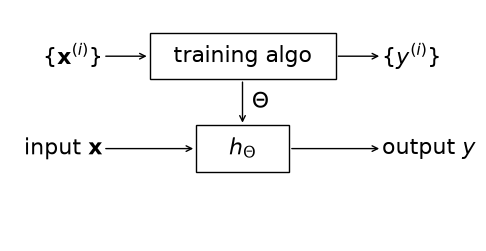

In [16]:
## Draw plot
# If one wants to avoid including images and is willing to create simple
# diagrams programmatically, one can use matplotlib to create diagrams.
import matplotlib.pyplot as plt

# Create a figure and axis
fig, ax = plt.subplots(figsize=(6,3))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.text(0.2, 0.8, r'$\{\mathbf{x}^{(i)}\}$', ha='right', va='center', fontsize=16)
ax.text(0.8, 0.8, r'$\{y^{(i)}\}$', ha='left', va='center', fontsize=16)

ax.add_patch(plt.Rectangle((0.3, 0.7), 0.4, 0.2, edgecolor='black', facecolor='none'))
ax.text(0.5, 0.8, 'training algo', ha='center', va='center', fontsize=16)

# Draw arrows into and out of the training algo box.
ax.annotate("", xy=(0.2, 0.8), xytext=(0.3, 0.8),
            arrowprops=dict(arrowstyle="<-"))
ax.annotate("", xy=(0.7, 0.8), xytext=(0.8, 0.8),
            arrowprops=dict(arrowstyle="<-"))

# Draw arrow from the training algo box to the hypothesis (model) box.
ax.annotate("", xy=(0.5, 0.7), xytext=(0.5, 0.5),
            arrowprops=dict(arrowstyle="<-"))
ax.text(0.52, 0.6, r'$\Theta$', ha='left', va='center', fontsize=16)


ax.add_patch(plt.Rectangle((0.4, 0.3), 0.2, 0.2, edgecolor='black', facecolor='none'))
ax.text(0.5, 0.4, r'$h_{\Theta}$', ha='center', va='center', fontsize=16)

ax.text(0.2, 0.4, 'input $\mathbf{x}$', ha='right', va='center', fontsize=16)
ax.text(0.8, 0.4, 'output $y$', ha='left', va='center', fontsize=16)

# Draw arrows into and out of the hypothesis (a.k.a., the model).
ax.annotate("", xy=(0.2, 0.4), xytext=(0.4, 0.4),
            arrowprops=dict(arrowstyle="<-"))
ax.annotate("", xy=(0.6, 0.4), xytext=(0.8, 0.4),
            arrowprops=dict(arrowstyle="<-"))

ax.axis('off')

plt.show()

For linear regression, there exists an equation that directly yields the
coefficients that minimize the sum square error.  It is known as the "normal equation."
Consider linear regression where $y$ is a function of a single variable $x$.


$$
  y = h_{\Theta}(x) = \Theta_0 + \Theta_1 x
$$

where $y$ estimates (a.k.a., predicts) the observed values $y^{(i)}$.

Given: a set of samples in a training data set ${(x^{(i)}, y^{(i)})}$
wherein $i \in [1,m]$ and $x^{(i)}$ is the $ith$ input and $y^{(i)}$ is
the real valued output associated with $x^{(i)}$.  $x \in \mathbb{R}$ and
$y \in \mathbb{R}$.

Find the "normal equation" that yields $(\Theta_0, \Theta_1)$ as a function
of $(x^{(i)}, y^{(i)})$ such that $(\Theta_0, \Theta_1)$ minimizes the following
cost function:

$$
\text{minimize } J(\Theta) = \sum_{i=1}^{m} \frac{1}{2} (h_{\Theta}(x^{(i)})-y^{(i)})^2
$$

Hint: the minimum occurs where the gradient is zero.  $\nabla J(\Theta) = 0$.

The gradient $\nabla J$ is given
$(\frac{\partial J}{\partial \Theta_0}, \frac{\partial J}{\partial \Theta_1})$.

At the minimum

\begin{equation}
   \bigg(\frac{\partial J}{\partial \Theta_0},
    \frac{\partial J}{\partial \Theta_1}\bigg) = 0
\end{equation}

All sums run over $i = 1, \dots, m$. The cost is

$$J(\Theta) = \frac12 \sum_{i=1}^m \left(\Theta_0 + \Theta_1 x^{(i)} - y^{(i)}\right)^2.$$

**Partial derivatives** (chain rule; the $\frac12$ cancels the 2 from the square):

$$\frac{\partial J}{\partial \Theta_0} = \sum_{i} \left(\Theta_0 + \Theta_1 x^{(i)} - y^{(i)}\right) \cdot 1$$

$$\frac{\partial J}{\partial \Theta_1} = \sum_{i} \left(\Theta_0 + \Theta_1 x^{(i)} - y^{(i)}\right) x^{(i)}$$

**Set both to zero.** This gives two linear equations, the *normal equations*:

$$
\begin{aligned}
m\,\Theta_0 + \Theta_1 \sum_i x^{(i)} &= \sum_i y^{(i)} \qquad &(1)\\
\Theta_0 \sum_i x^{(i)} + \Theta_1 \sum_i \left(x^{(i)}\right)^2 &= \sum_i x^{(i)} y^{(i)} \qquad &(2)
\end{aligned}
$$

**Solve.** From (1), $\Theta_0 = \frac{1}{m}\left(\sum_i y^{(i)} - \Theta_1 \sum_i x^{(i)}\right)$. Substitute into (2) and multiply by $m$:

$$\sum_i x^{(i)}\sum_i y^{(i)} - \Theta_1\Big(\sum_i x^{(i)}\Big)^2 + m\,\Theta_1 \sum_i \left(x^{(i)}\right)^2 = m\sum_i x^{(i)} y^{(i)}$$

$$
\boxed{\;\Theta_1 = \frac{m\sum_i x^{(i)}y^{(i)} - \sum_i x^{(i)}\sum_i y^{(i)}}{m\sum_i \left(x^{(i)}\right)^2 - \Big(\sum_i x^{(i)}\Big)^2}\;},
\qquad
\boxed{\;\Theta_0 = \frac{\sum_i y^{(i)} - \Theta_1\sum_i x^{(i)}}{m}
= \frac{\sum_i \left(x^{(i)}\right)^2 \sum_i y^{(i)} - \sum_i x^{(i)} \sum_i x^{(i)} y^{(i)}}{m\sum_i \left(x^{(i)}\right)^2 - \Big(\sum_i x^{(i)}\Big)^2}\;}
$$

Equivalently, with sample means $\bar x, \bar y$:
$\Theta_1 = \dfrac{\sum_i (x^{(i)} - \bar x)(y^{(i)} - \bar y)}{\sum_i (x^{(i)} - \bar x)^2}$ and $\Theta_0 = \bar y - \Theta_1 \bar x$.

**Matrix form.** Let $X$ be the $m \times 2$ design matrix whose $i$-th row is $[1,\; x^{(i)}]$, and let $\mathbf{y} = [y^{(1)}, \dots, y^{(m)}]^T$.
Equations (1) and (2) are exactly $X^T X\,\Theta = X^T \mathbf{y}$, so

$$\Theta = (X^T X)^{-1} X^T \mathbf{y}.$$

**It is a minimum.** The Hessian is
$\nabla^2 J = X^TX = \begin{bmatrix} m & \sum_i x^{(i)} \\ \sum_i x^{(i)} & \sum_i (x^{(i)})^2 \end{bmatrix}$.
Its determinant is $m\sum_i (x^{(i)})^2 - (\sum_i x^{(i)})^2 = m\sum_i (x^{(i)} - \bar x)^2 > 0$ as long as not all $x^{(i)}$ are equal, and $m > 0$.
So $J$ is strictly convex and the stationary point is the unique global minimum. The same condition keeps the denominator above nonzero.

In [17]:
# Numerical check: the normal equation matches numpy's least-squares fit.
rng = np.random.default_rng(0)
m = 50
x = rng.uniform(0, 10, m)
y = 3.0 + 2.0 * x + rng.normal(0, 1, m)      # true Theta_0 = 3, Theta_1 = 2, plus noise

theta1 = (m * np.sum(x * y) - np.sum(x) * np.sum(y)) / (m * np.sum(x**2) - np.sum(x)**2)
theta0 = (np.sum(y) - theta1 * np.sum(x)) / m

X = np.column_stack([np.ones(m), x])          # design matrix, rows [1, x_i]
theta_matrix = np.linalg.solve(X.T @ X, X.T @ y)

print("scalar normal equation:", theta0, theta1)
print("matrix normal equation:", theta_matrix)
print("np.polyfit            :", np.polyfit(x, y, 1)[::-1])

scalar normal equation: 2.7574711459591685 2.052336201837264
matrix normal equation: [2.75747115 2.0523362 ]
np.polyfit            : [2.75747115 2.0523362 ]
